# 
IFRS 9 — PIT PD Modelling in Python (Date-Split, Leakage-Safe)
This notebook performs a **chronological train/validation split (70/30)** to avoid look-ahead bias, then fits a logistic regression with a robust preprocessing pipeline and computes the full suite of model metrics:
- ROC/AUC/Gini (overall/train/valid)
- KS by role + KS curve
- Lift & Gains (point & cumulative)
- Hosmer–Lemeshow partition (VALID)
- Brier score (overall/by role)
- Association metrics and fit statistics
- PSI using TRAIN decile cuts

**Dataset**: `/mnt/data/ifrs9_pit_pd_intro_final.csv`

## 0. Imports & Helpers

In [3]:
import numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss, log_loss

# Display settings
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', 120)

def display_df(title, df, head=10):
    print(f"\n=== {title} ===")
    try:
        display(df if head is None else df.head(head))
    except NameError:
        # Fallback if display() unavailable
        print(df if head is None else df.head(head))

## 1. Load Data

In [5]:
# Change this path if running locally (e.g., on Windows)
in_csv = 'C:/Users/customer/Desktop/MyVideos/UDEMY LESSONS/IFRS 9 Python/Module 3 Dataset/ifrs9_pit_pd_intro_final.csv'
df = pd.read_csv(in_csv)
display_df("Head()", df)


=== Head() ===


,loan_origination_date,report_date,default_date,loan_age_m,credit_utilization,dpd,internal_score,age,macro_gdp_growth,macro_unemployment,macro_interest_rate,LGD,EAD,default_flag,account_id,employment_status,marital_status,dependents,region,stage
0,10/25/2021,3/1/2024,NaN,29,0.42,99,551,36,4.33,4.51,3.36,0.405836,59524.80636,0,9449975,Employed,Single,3,West,3
1,6/11/2018,5/1/2022,8/10/2022,47,1.00,139,868,66,0.29,6.18,2.36,0.693087,145931.71780,1,6228566,Employed,Married,0,West,3
2,2/20/2021,8/1/2024,NaN,42,0.43,27,351,57,2.29,4.14,3.41,0.418884,33587.13655,0,3844180,Employed,Divorced,0,South,2
3,12/22/2017,9/1/2024,NaN,81,1.00,154,755,21,2.50,6.88,3.23,0.700000,148398.19620,0,6931161,Employed,Married,3,South,3
4,12/4/2021,7/1/2022,10/25/2022,7,0.73,119,802,38,3.31,4.32,2.90,0.539792,129156.58160,1,2655016,Employed,Married,2,West,3
5,3/22/2017,1/1/2024,NaN,82,0.82,5,498,28,2.53,6.05,3.70,0.589293,102515.35760,0,8887739,Employed,Divorced,2,North,2
6,11/8/2018,11/1/2023,NaN,60,0.91,147,561,37,1.76,4.58,2.92,0.700000,162469.65300,0,7189573,Employed,Married,3,East,3
7,2/25/2019,4/1/2022,NaN,38,1.00,90,860,58,2.75,3.61,2.86,0.700000,164755.49640,0,2034586,Self-Employed,Married,0,South,3
8,5/26/2019,4/1/2022,3/6/2023,35,0.62,0,761,55,2.52,6.66,3.37,0.467526,83315.33356,1,6445315,Employed,Married,1,North,2
9,7/21/2016,10/1/2023,NaN,87,0.36,98,822,45,2.01,2.34,3.18,0.375128,56169.40725,0,7529845,Self-Employed,Single,4,South,3


## 2. Target Detection & Cleaning

In [7]:
possible_targets = ['default_flag','default_12m','bad_flag','event','target']
target = next((c for c in possible_targets if c in df.columns), None)
assert target is not None, f"No binary target column found. Expected one of: {possible_targets}"

# Coerce to {0,1}
df[target] = pd.to_numeric(df[target], errors='coerce').fillna(0).astype(int)
df[target] = (df[target] > 0).astype(int)
print("Target:", target, "| Event rate:", round(df[target].mean(), 4))

Target: default_flag | Event rate: 0.4686


## 3. Chronological Train/Validation Split (70/30)

In [9]:
# Detect a date column
possible_dates = ['report_date','snapshot_month','as_of_date','date','reporting_date']
date_col = next((c for c in possible_dates if c in df.columns), None)
assert date_col is not None, f"No date column found. Expected one of: {possible_dates}"

# Parse & sort
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
assert df[date_col].notna().any(), f"All values in {date_col} are NaT after parsing."
df = df.sort_values(date_col).reset_index(drop=True)

# 70% oldest -> TRAIN; 30% newest -> VALID
cutoff = int(0.7 * len(df))
train = df.iloc[:cutoff].copy()
valid = df.iloc[cutoff:].copy()
train['role'] = 'TRAIN'; valid['role'] = 'VALID'

print("Date column:", date_col)
print(f"TRAIN: {len(train)} rows  |  VALID: {len(valid)} rows")
display_df("TRAIN date range", train[[date_col]].agg(['min','max']))
display_df("VALID date range", valid[[date_col]].agg(['min','max']))

Date column: report_date
TRAIN: 3500 rows  |  VALID: 1500 rows

=== TRAIN date range ===


,report_date
min,2022-01-01
max,2024-02-01



=== VALID date range ===


,report_date
min,2024-02-01
max,2024-12-01


## 4. Features & Preprocessing Pipeline

In [11]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
import inspect
import pandas as pd

# --- Columns ---
exclude   = {target, 'role','pred_pd','P_1','y_pred','linpred','id','account_id'}
features  = [c for c in df.columns if c not in exclude and c != date_col]
num_cols  = [c for c in features if pd.api.types.is_numeric_dtype(df[c])]
cat_cols  = [c for c in features if c not in num_cols]
assert len(num_cols) + len(cat_cols) > 0, "No predictors available after exclusions."
print(f"Numeric cols: {len(num_cols)} | Categorical cols: {len(cat_cols)}")

# --- Version-safe OneHotEncoder kwargs ---
ohe_kwargs = {'handle_unknown': 'ignore'}
if 'sparse_output' in inspect.signature(OneHotEncoder).parameters:
    ohe_kwargs['sparse_output'] = False   # sklearn ≥ 1.4
else:
    ohe_kwargs['sparse'] = False          # sklearn ≤ 1.3

# --- Pipelines ---
num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median'))])

transformers = [('num', num_pipe, num_cols)]
if len(cat_cols) > 0:
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(**ohe_kwargs))
    ])
    transformers.append(('cat', cat_pipe, cat_cols))

pre = ColumnTransformer(transformers=transformers, remainder='drop')

clf = Pipeline([
    ('pre', pre),
    ('logit', LogisticRegression(max_iter=200, solver='liblinear'))
])


Numeric cols: 12 | Categorical cols: 5


## 5. Fit & Score

In [13]:
X_tr, y_tr = train[features], train[target]
X_va, y_va = valid[features], valid[target]
clf.fit(X_tr, y_tr)

train_out = train.copy(); valid_out = valid.copy()
train_out['pred_pd'] = clf.predict_proba(X_tr)[:,1]
valid_out['pred_pd'] = clf.predict_proba(X_va)[:,1]
scored = pd.concat([train_out, valid_out], ignore_index=True)

display_df("Scored (head)", scored[['role', target, 'pred_pd']])


=== Scored (head) ===


,role,default_flag,pred_pd
0,TRAIN,1,0.906737
1,TRAIN,0,0.032850
2,TRAIN,1,0.970488
3,TRAIN,1,0.973247
4,TRAIN,0,0.065753
5,TRAIN,1,0.956564
6,TRAIN,1,0.916862
7,TRAIN,0,0.067021
8,TRAIN,0,0.009424
9,TRAIN,0,0.020433


## 6. ROC / AUC / Gini + ROC Curve


=== C-stat & Gini ===


,sample,C_stat,Gini
0,OVERALL,0.9987,0.9974
1,TRAIN,0.9981,0.9963
2,VALID,1.0000,1.0000


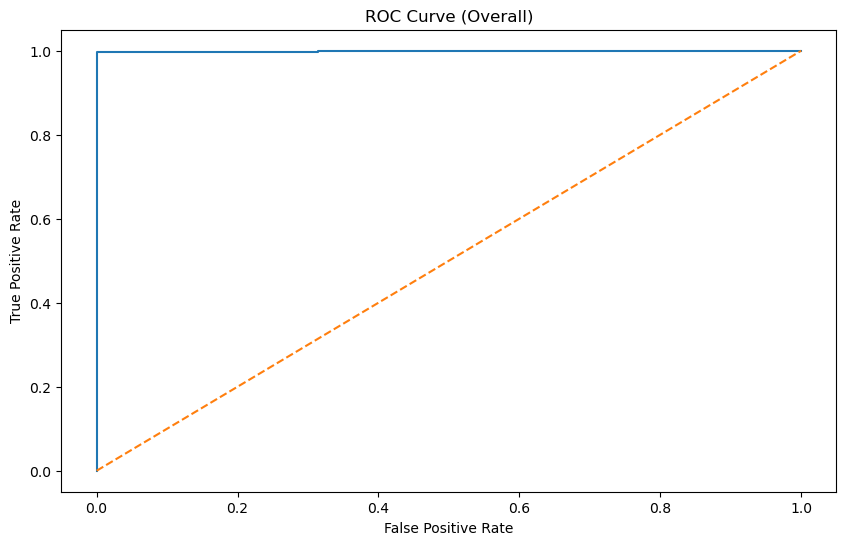

In [53]:
def auc_gini(y, p):
    auc = roc_auc_score(y, p); gini = 2*auc - 1; return auc, gini

auc_overall, gini_overall = auc_gini(scored[target], scored['pred_pd'])
auc_train, gini_train     = auc_gini(train_out[target], train_out['pred_pd'])
auc_valid, gini_valid     = auc_gini(valid_out[target], valid_out['pred_pd'])

auc_table = pd.DataFrame({'sample':['OVERALL','TRAIN','VALID'],
                          'C_stat':[auc_overall, auc_train, auc_valid],
                          'Gini':[gini_overall, gini_train, gini_valid]}).round(4)
display_df("C-stat & Gini", auc_table, head=None)

fpr, tpr, _ = roc_curve(scored[target], scored['pred_pd'])
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve (Overall)')
plt.show()

## 7. KS by Role + KS Curve (VALID if available)


=== KS by role ===


,role,KS
0,TRAIN,0.927938
1,VALID,0.955414


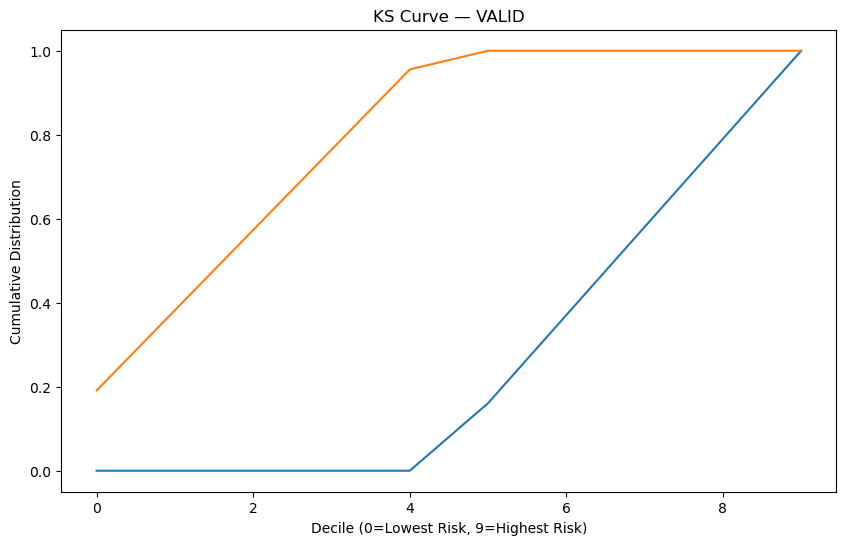

In [17]:
def ks_by_role(frame, y_col, p_col, role_col='role', groups=10):
    out = {}; rows = []
    for role, g in frame.groupby(role_col):
        g = g[[y_col, p_col]].dropna().copy()
        g['decile'] = pd.qcut(g[p_col].rank(method='first'), q=groups, labels=False, duplicates='drop')
        agg = g.groupby('decile').agg(bad=(y_col,'sum'), pop=(y_col,'count'))
        agg['good'] = agg['pop'] - agg['bad']
        agg = agg.sort_index()
        agg['cum_bad'] = agg['bad'].cumsum()
        agg['cum_good'] = agg['good'].cumsum()
        tb, tg = max(agg['bad'].sum(),1), max(agg['good'].sum(),1)
        agg['cdf_bad'] = agg['cum_bad']/tb; agg['cdf_good'] = agg['cum_good']/tg
        agg['ks'] = (agg['cdf_bad'] - agg['cdf_good']).abs()
        rows.append({'role':role, 'KS':float(agg['ks'].max())})
        out[role] = agg
    return pd.DataFrame(rows), out

ks_table, ks_curves = ks_by_role(scored, y_col=target, p_col='pred_pd')
display_df("KS by role", ks_table, head=None)

role_for_curve = 'VALID' if 'VALID' in ks_curves else list(ks_curves.keys())[0]
agg = ks_curves[role_for_curve]

plt.figure()
plt.plot(agg.index, agg['cdf_bad'])
plt.plot(agg.index, agg['cdf_good'])
plt.xlabel('Decile (0=Lowest Risk, 9=Highest Risk)'); plt.ylabel('Cumulative Distribution'); plt.title(f'KS Curve — {role_for_curve}')
plt.show()

## 8. Lift & Gains (Top-Down) + Charts


=== Lift & Gains (top rows) ===


,role,decile,decile_desc,pop,bad,good,resp_rate,lift,cum_pct_pop,gains,cum_lift
0,TRAIN,9,0,350,350,0,1.0000,2.1499,0.1,0.2150,2.1499
1,TRAIN,8,1,350,350,0,1.0000,2.1499,0.2,0.4300,2.1499
2,TRAIN,7,2,350,350,0,1.0000,2.1499,0.3,0.6450,2.1499
3,TRAIN,6,3,350,350,0,1.0000,2.1499,0.4,0.8600,2.1499
4,TRAIN,5,4,350,222,128,0.6343,1.3636,0.5,0.9963,1.9926
5,TRAIN,4,5,350,1,349,0.0029,0.0061,0.6,0.9969,1.6615
6,TRAIN,3,6,350,1,349,0.0029,0.0061,0.7,0.9975,1.4251
7,TRAIN,2,7,350,2,348,0.0057,0.0123,0.8,0.9988,1.2485
8,TRAIN,1,8,350,1,349,0.0029,0.0061,0.9,0.9994,1.1104
9,TRAIN,0,9,350,1,349,0.0029,0.0061,1.0,1.0000,1.0000


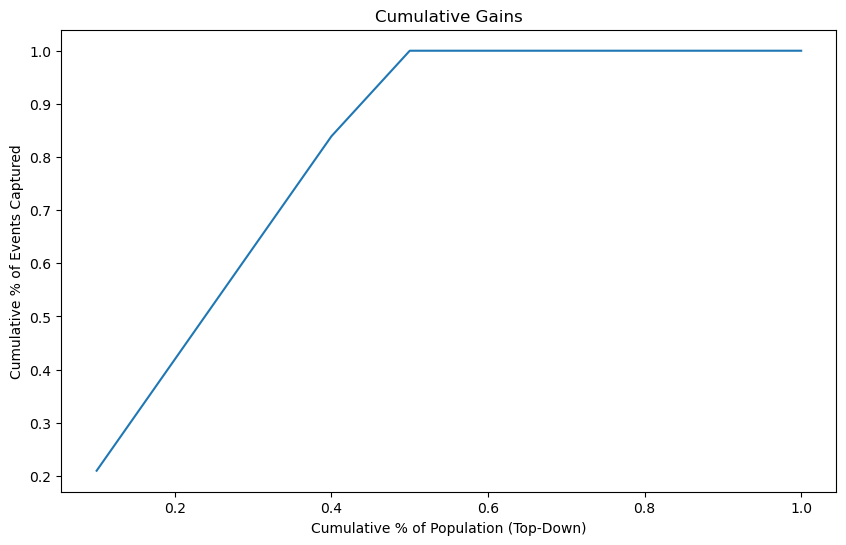

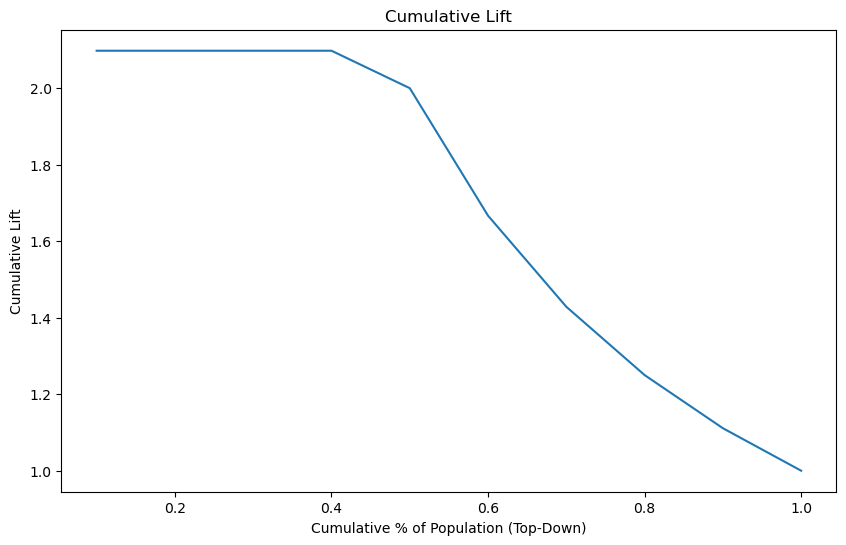

In [19]:
def lift_gains(frame, y_col, p_col, role_col='role', groups=10):
    rows = []
    for role, g in frame.groupby(role_col):
        g = g[[y_col, p_col]].dropna().copy()
        g['decile'] = pd.qcut(g[p_col].rank(method='first'), q=groups, labels=False, duplicates='drop')
        agg = g.groupby('decile').agg(bad=(y_col,'sum'), pop=(y_col,'count'))
        agg['good'] = agg['pop'] - agg['bad']
        total_bad, total_pop = max(agg['bad'].sum(),1), max(agg['pop'].sum(),1)
        overall_rt = total_bad/total_pop
        agg = agg.sort_index(ascending=False).copy()
        agg['cum_resp'] = agg['bad'].cumsum()
        agg['cum_pop']  = agg['pop'].cumsum()
        agg['resp_rate'] = agg['bad']/agg['pop'].replace(0, np.nan)
        agg['lift'] = agg['resp_rate']/overall_rt
        agg['cum_pct_pop'] = agg['cum_pop']/total_pop
        agg['gains'] = agg['cum_resp']/total_bad
        agg['cum_lift'] = agg['gains']/agg['cum_pct_pop'].replace(0, np.nan)
        agg['role'] = role; agg['decile_desc'] = np.arange(len(agg))
        rows.append(agg.reset_index())
    out = pd.concat(rows, ignore_index=True)
    return out[['role','decile','decile_desc','pop','bad','good','resp_rate','lift','cum_pct_pop','gains','cum_lift']]

lg = lift_gains(scored, target, 'pred_pd')
display_df("Lift & Gains (top rows)", lg.round(4))

lg_valid = lg[lg['role']=='VALID'].copy() if (lg['role']=='VALID').any() else lg.copy()
plt.figure()
plt.plot(lg_valid['cum_pct_pop'], lg_valid['gains'])
plt.xlabel('Cumulative % of Population (Top-Down)'); plt.ylabel('Cumulative % of Events Captured'); plt.title('Cumulative Gains')
plt.show()

plt.figure()
plt.plot(lg_valid['cum_pct_pop'], lg_valid['cum_lift'])
plt.xlabel('Cumulative % of Population (Top-Down)'); plt.ylabel('Cumulative Lift'); plt.title('Cumulative Lift')
plt.show()

## 9. Hosmer–Lemeshow (VALID Only)


=== Hosmer–Lemeshow Partition (VALID) ===


,Group,Total,EventsObserved,EventsExpected
0,1,150,0,2.926278
1,2,150,0,4.921448
2,3,150,0,7.002279
3,4,150,0,9.953083
4,5,150,0,15.793340
5,6,150,115,105.573748
6,7,150,150,138.691276
7,8,150,150,142.062699
8,9,150,150,144.165431
9,10,150,150,145.998769


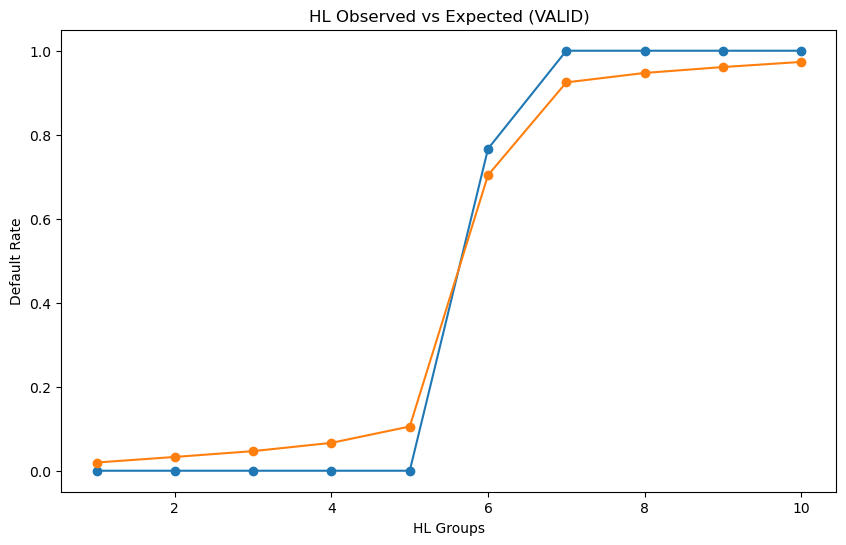

In [21]:
def hosmer_lemeshow(y_true, y_prob, bins=10):
    order = np.argsort(y_prob)
    y_true = np.array(y_true)[order]; y_prob = np.array(y_prob)[order]
    n = len(y_true); groups = []
    for k in range(bins):
        s = int(round(k*n/bins)); e = int(round((k+1)*n/bins))
        y_g = y_true[s:e]; p_g = y_prob[s:e]
        groups.append((k+1, len(y_g), y_g.sum(), p_g.sum()))
    return pd.DataFrame(groups, columns=['Group','Total','EventsObserved','EventsExpected'])

hl_table = hosmer_lemeshow(valid[target], valid_out['pred_pd'], bins=10)
display_df("Hosmer–Lemeshow Partition (VALID)", hl_table, head=None)

hlp = hl_table.copy()
hlp['ObsRate'] = hlp['EventsObserved']/hlp['Total'].replace(0, np.nan)
hlp['ExpRate'] = hlp['EventsExpected']/hlp['Total'].replace(0, np.nan)

plt.figure()
plt.plot(hlp['Group'], hlp['ObsRate'], marker='o')
plt.plot(hlp['Group'], hlp['ExpRate'], marker='o')
plt.xlabel('HL Groups'); plt.ylabel('Default Rate'); plt.title('HL Observed vs Expected (VALID)')
plt.show()

## 10. Brier Score (Overall/By Role) + Distribution


=== Brier Score ===


,sample,BrierScore
0,OVERALL,0.006353
1,TRAIN,0.006872
2,VALID,0.005141


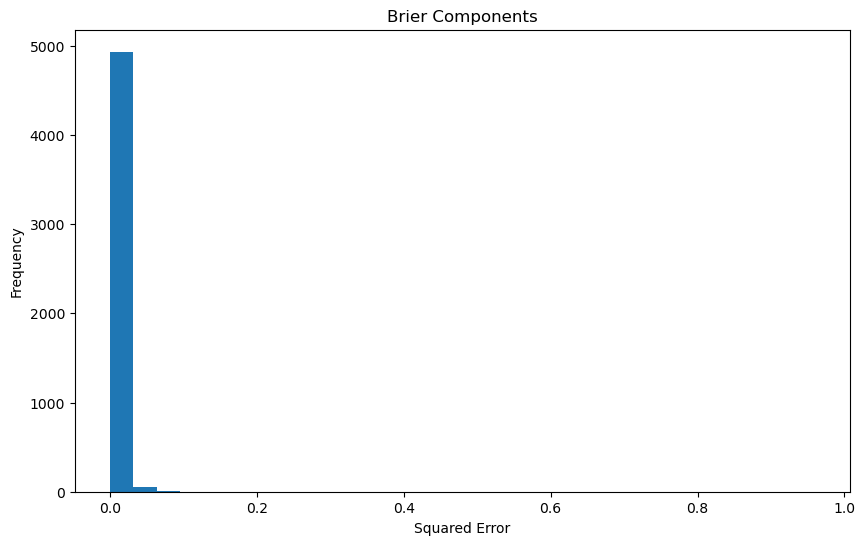

In [23]:
brier_tbl = pd.DataFrame({
    'sample':['OVERALL','TRAIN','VALID'],
    'BrierScore':[brier_score_loss(scored[target], scored['pred_pd']),
                  brier_score_loss(train_out[target], train_out['pred_pd']),
                  brier_score_loss(valid_out[target], valid_out['pred_pd'])]
}).round(6)
display_df("Brier Score", brier_tbl, head=None)

plt.figure()
plt.hist((scored['pred_pd'] - scored[target])**2, bins=30)
plt.xlabel('Squared Error'); plt.ylabel('Frequency'); plt.title('Brier Components')
plt.show()

## 11. Association & Fit Statistics (VALID)

In [25]:
auc_valid = roc_auc_score(valid_out[target], valid_out['pred_pd'])
assoc_tbl = pd.DataFrame({'Metric':['AUC (VALID)','SomersD (VALID)','Gini (VALID)'],
                          'Value':[auc_valid, 2*auc_valid-1, 2*auc_valid-1]}).round(4)
display_df("Association Metrics (VALID)", assoc_tbl, head=None)

ll_model = -len(valid_out) * log_loss(valid_out[target], valid_out['pred_pd'], eps=1e-15)
p0 = valid_out[target].mean()
ll_null  = -len(valid_out) * log_loss(valid_out[target], np.full(len(valid_out), p0), eps=1e-15)
pseudo_r2 = 1 - (ll_model/ll_null) if ll_null != 0 else np.nan
fit_tbl = pd.DataFrame({'Statistic':['LogLik (Model, VALID)','LogLik (Null, VALID)','McFadden R2 (VALID)'],
                        'Value':[ll_model, ll_null, pseudo_r2]}).round(4)
display_df("Fit Statistics (VALID)", fit_tbl, head=None)


=== Association Metrics (VALID) ===


,Metric,Value
0,AUC (VALID),1.0
1,SomersD (VALID),1.0
2,Gini (VALID),1.0



=== Fit Statistics (VALID) ===


C:\Users\customer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:2910: FutureWarning: Setting the eps parameter is deprecated and will be removed in 1.5. Instead eps will always havea default value of `np.finfo(y_pred.dtype).eps`.
  warnings.warn(
C:\Users\customer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:2910: FutureWarning: Setting the eps parameter is deprecated and will be removed in 1.5. Instead eps will always havea default value of `np.finfo(y_pred.dtype).eps`.
  warnings.warn(


,Statistic,Value
0,"LogLik (Model, VALID)",-94.9568
1,"LogLik (Null, VALID)",-1038.0868
2,McFadden R2 (VALID),0.9085


## 12. PSI — TRAIN Cuts Applied to VALID


=== PSI by Bin (TRAIN cuts) — Total=0.0143 ===


,bin,train_pct,valid_pct,psi_bin
0,0,0.1,0.100000,0.000000
1,1,0.1,0.077333,0.005826
2,2,0.1,0.096667,0.000113
3,3,0.1,0.104667,0.000213
4,4,0.1,0.092667,0.000559
5,5,0.1,0.115333,0.002187
6,6,0.1,0.094000,0.000371
7,7,0.1,0.115333,0.002187
8,8,0.1,0.090000,0.001054
9,9,0.1,0.114000,0.001834


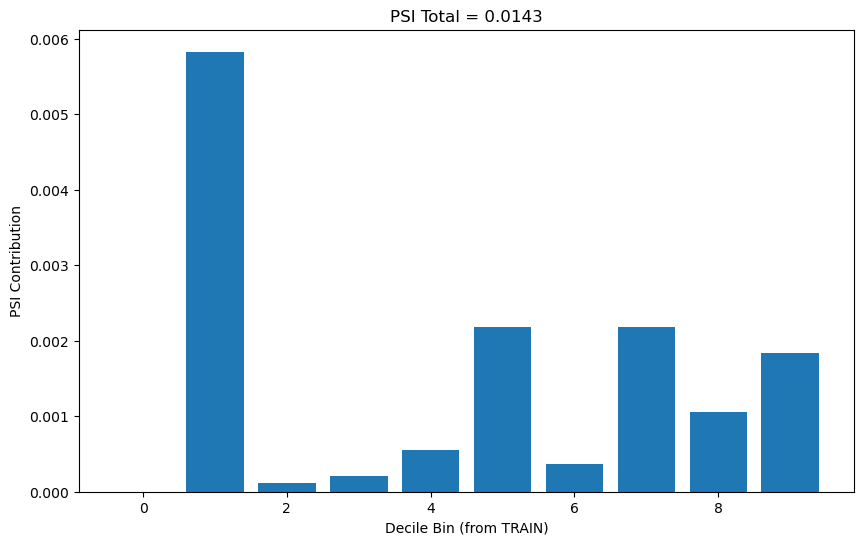

In [27]:
def psi_from_deciles(train_scores, valid_scores, bins=10, min_prop=1e-4):
    qs = np.quantile(train_scores, np.linspace(0,1,bins+1))
    qs = np.unique(qs)  # ensure monotonic
    def assign(x, edges): return np.digitize(x, edges[1:-1], right=True)
    tr_b = assign(train_scores, qs); va_b = assign(valid_scores, qs)
    idx = range(len(qs)-1)
    tr = pd.Series(tr_b).value_counts().sort_index().reindex(idx, fill_value=0).astype(float)
    va = pd.Series(va_b).value_counts().sort_index().reindex(idx, fill_value=0).astype(float)
    tr_pct = (tr / max(tr.sum(),1)).clip(lower=min_prop)
    va_pct = (va / max(va.sum(),1)).clip(lower=min_prop)
    psi_bin = (va_pct - tr_pct) * np.log(va_pct / tr_pct)
    psi_total = float(psi_bin.sum())
    return psi_total, pd.DataFrame({'bin':list(idx),'train_pct':tr_pct.values,'valid_pct':va_pct.values,'psi_bin':psi_bin.values})

psi_total, psi_table = psi_from_deciles(train_out['pred_pd'].values, valid_out['pred_pd'].values, bins=10)
display_df(f"PSI by Bin (TRAIN cuts) — Total={psi_total:.4f}", psi_table.round(6), head=None)

plt.figure()
plt.bar(psi_table['bin'], psi_table['psi_bin'])
plt.xlabel('Decile Bin (from TRAIN)'); plt.ylabel('PSI Contribution'); plt.title(f'PSI Total = {psi_total:.4f}')
plt.show()

## 13. Save CSV Outputs for Students

In [29]:
out_dir = Path('/mnt/data/ifrs9_python_outputs_date_split'); out_dir.mkdir(exist_ok=True, parents=True)
scored.to_csv(out_dir/'scored_predictions.csv', index=False)
auc_table.to_csv(out_dir/'auc_table.csv', index=False)
ks_table.to_csv(out_dir/'ks_by_role.csv', index=False)
lg.to_csv(out_dir/'lift_gains.csv', index=False)
hl_table.to_csv(out_dir/'hl_partition_valid.csv', index=False)
brier_tbl.to_csv(out_dir/'brier_scores.csv', index=False)
assoc_tbl.to_csv(out_dir/'association_metrics_valid.csv', index=False)
fit_tbl.to_csv(out_dir/'fit_statistics_valid.csv', index=False)
psi_table.to_csv(out_dir/'psi_by_bin.csv', index=False)
print('Saved to', out_dir)

Saved to \mnt\data\ifrs9_python_outputs_date_split
